In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak

In [2]:
fpaths = glob.glob("/eos/home-b/bewilson/analysis_output-v3/*.root")
print(f"found {len(fpaths)} files")

found 555 files


In [3]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

good_runs = wissals_2022_runs + wissals_2023_runs + wissals_2024_noCaloNu_runs + wissals_2024_CaloNu_runs

In [4]:
print(f"Total number of good runs: {len(good_runs)}")

Total number of good runs: 305


In [5]:
cutflow = {}

runs_with_missing_waveforms = {}
complete_runs = set()
total_number_of_events = 0

run_yields = {}

for fpath in tqdm.tqdm(fpaths):
    with uproot.open(fpath) as f:
        tree = f["cutflow"]
        lumi = f["meta"].arrays(library="pd")["lumi"][0]
        df = tree.arrays(library="pd")

        # print(f"Run {fpath} has lumi {lumi}")
        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        if run not in good_runs:
            # print(f"Run {run} is not in the good runs list, skipping")
            continue

        
        # if len(lumi) == 0 or lumi == 0:
        #     # print(f"Run {fpath} has zero lumi, skipping")
        #     continue

    for idx, row in df.iterrows():
        cut = row["cut_name"]
        all = row["all"]
        passed = row["passed"]

        if cut not in cutflow:
            cutflow[cut] = {"all": 0, "passed": 0}

        cutflow[cut]["all"] += all
        cutflow[cut]["passed"] += passed
    
    all_events = np.amax(df["all"])
    final_yield = np.amin(df["passed"])
    total_number_of_events += all_events
    run_yields[int(run)] = final_yield


    # print(f"{total_number_of_events:,.2g}")
    
    # all_in_ = cutflow["Sanity check for aux lookup"]["all"]
    # passed_in_ = cutflow["Sanity check for aux lookup"]["passed"]

    # if all_in_ != passed_in_:
    #     runs_with_missing_waveforms[run] = (all_in_, passed_in_)
    # else:
    #     complete_runs.add(run)

100%|██████████| 555/555 [01:38<00:00,  5.65it/s]


In [6]:
print(f"Found {len(runs_with_missing_waveforms)} runs with missing waveforms:")

n_2022_runs = 0
n_2023_runs = 0
n_2024_preCaloNu_runs = 0
n_2024_CaloNu_runs = 0
n_2024_afterCaloNu_runs = 0

n_2022_missing_waveforms = 0
n_2023_missing_waveforms = 0
n_2024_preCaloNu_missing_waveforms = 0
n_2024_CaloNu_missing_waveforms = 0
n_2024_afterCaloNu_missing_waveforms = 0

for run, events in runs_with_missing_waveforms.items():
    all_, passed_ = events
    missing = all_ - passed_

    # if missing == 1: continue # ignore runs with only 1 missing waveform

    run = int(run)
    if run < 1e4: # 2022
        n_2022_runs += 1
        n_2022_missing_waveforms += missing
        print(f"{n_2022_missing_waveforms:,.2g}")
    elif run < 1.2e4: # 2023
        n_2023_runs += 1
        n_2023_missing_waveforms += missing
    elif 15821 < run < 16924: # 2024_CaloNu
        n_2024_CaloNu_runs += 1
        n_2024_CaloNu_missing_waveforms += missing
    elif run < 15821: # 2024_preCaloNu
        n_2024_preCaloNu_runs += 1
        n_2024_preCaloNu_missing_waveforms += missing
    elif run > 16924: # 2024_afterCaloNu
        n_2024_afterCaloNu_runs += 1
        n_2024_afterCaloNu_missing_waveforms += missing

    print(f"{run}: {all_} total, {passed_} passed, {missing} missing waveforms. percent missing: {missing/total_number_of_events:.2%}")   

print(f"2022 runs with missing waveforms: {n_2022_runs}")
print(f"2023 runs with missing waveforms: {n_2023_runs}")
print(f"2024_preCaloNu runs with missing waveforms: {n_2024_preCaloNu_runs}")
print(f"2024_CaloNu runs with missing waveforms: {n_2024_CaloNu_runs}")
print(f"2024_afterCaloNu runs with missing waveforms: {n_2024_afterCaloNu_runs}")

print(f"2022 missing waveforms: {n_2022_missing_waveforms}")
print(f"2023 missing waveforms: {n_2023_missing_waveforms}")
print(f"2024_preCaloNu missing waveforms: {n_2024_preCaloNu_missing_waveforms}")
print(f"2024_CaloNu missing waveforms: {n_2024_CaloNu_missing_waveforms}")
print(f"2024_afterCaloNu missing waveforms: {n_2024_afterCaloNu_missing_waveforms}")

Found 0 runs with missing waveforms:
2022 runs with missing waveforms: 0
2023 runs with missing waveforms: 0
2024_preCaloNu runs with missing waveforms: 0
2024_CaloNu runs with missing waveforms: 0
2024_afterCaloNu runs with missing waveforms: 0
2022 missing waveforms: 0
2023 missing waveforms: 0
2024_preCaloNu missing waveforms: 0
2024_CaloNu missing waveforms: 0
2024_afterCaloNu missing waveforms: 0


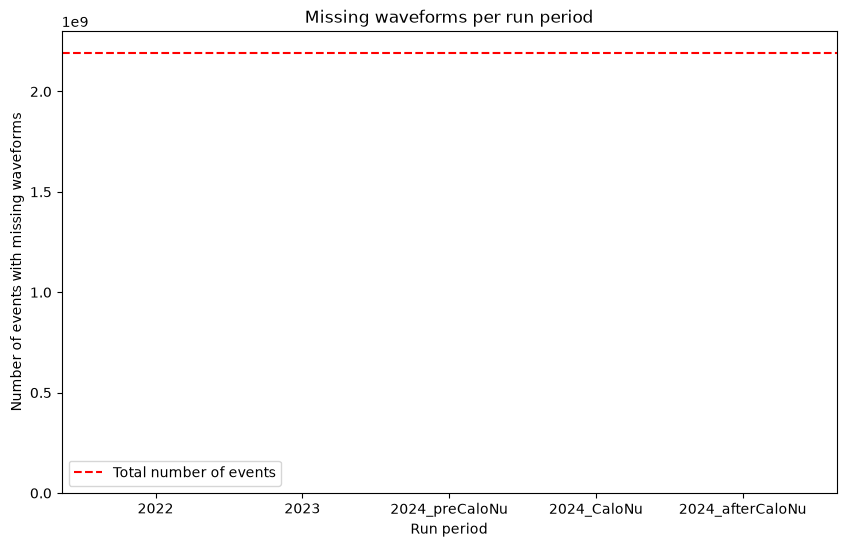

In [7]:
# plot missing waveforms per period
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["2022", "2023", "2024_preCaloNu", "2024_CaloNu", "2024_afterCaloNu"],
       [n_2022_missing_waveforms, n_2023_missing_waveforms, n_2024_preCaloNu_missing_waveforms, n_2024_CaloNu_missing_waveforms, n_2024_afterCaloNu_missing_waveforms])
ax.axhline(y=total_number_of_events, color='r', linestyle='--', label='Total number of events')
ax.set_ylabel("Number of events with missing waveforms")
ax.set_xlabel("Run period")
ax.set_title("Missing waveforms per run period")
# ax.set_yscale("log")
# ax.set_ylim(1, total_number_of_events*10
ax.legend()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'Colliding'),
  Text(1, 0, 'Trigger'),
  Text(2, 0, 'Good times'),
  Text(3, 0, 'Excluded times'),
  Text(4, 0, 'Sanity cut to remove events with missing aux data'),
  Text(5, 0, 'VetoNu0 reduced charge < 30 pC'),
  Text(6, 0, 'VetoNu1 reduced charge < 30 pC'),
  Text(7, 0, 'VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid)'),
  Text(8, 0, 'VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid)'),
  Text(9, 0, 'CaloNu status cleaning'),
  Text(10, 0, 'Veto20 and Veto21 charge > 40 pC'),
  Text(11, 0, 'Timing Station Charge > 20 pC'),
  Text(12, 0, 'Preshower Charge > 2.5 pC'),
  Text(13, 0, 'At least one long track'),
  Text(14, 0, 'Leading track has at >= 7 layers'),
  Text(15, 0, 'Track nDoF >= 9'),
  Text(16, 0, 'Leading track has chi2/ndof < 15'),
  Text(17, 0, 'Track pz > 100 GeV'),
  Text(18, 0, 

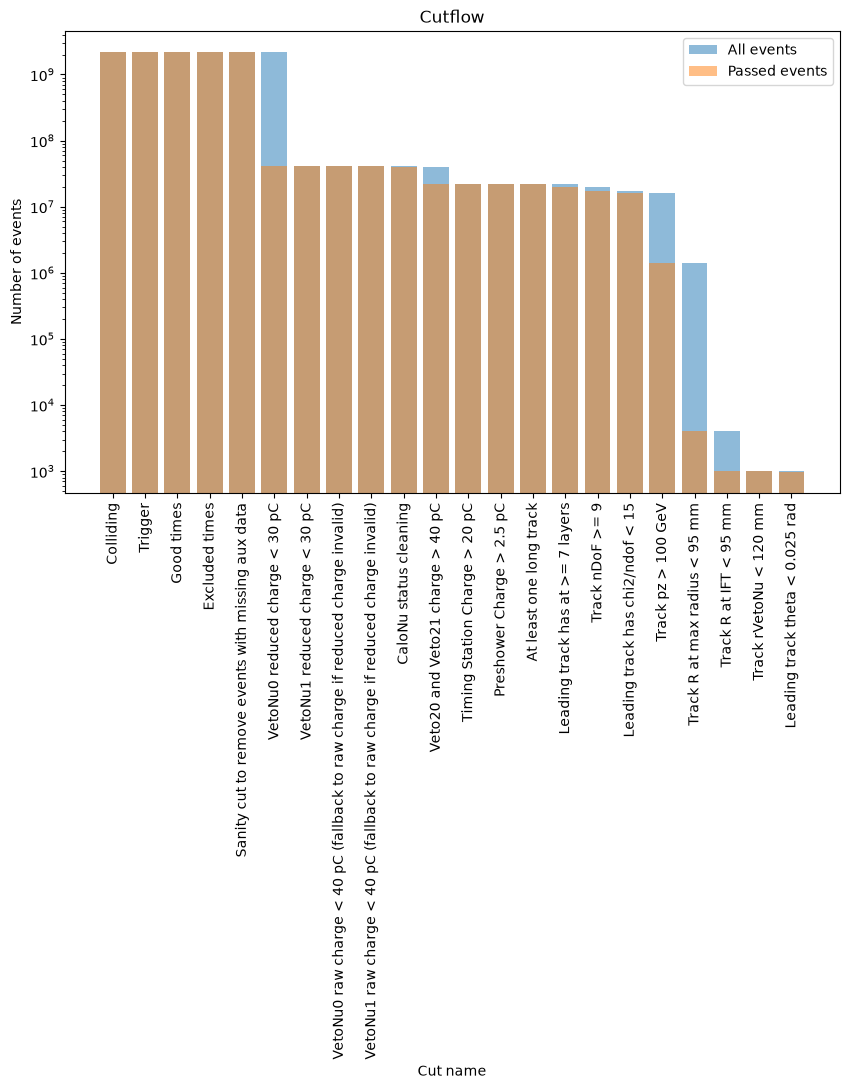

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cutflow.keys(), [cutflow[cut]["all"] for cut in cutflow.keys()], label="All events", alpha=0.5)
ax.bar(cutflow.keys(), [cutflow[cut]["passed"] for cut in cutflow.keys()], label="Passed events", alpha=0.5)
ax.set_yscale("log")
ax.set_ylabel("Number of events")
ax.set_xlabel("Cut name")
ax.set_title("Cutflow")
ax.legend()
plt.xticks(rotation=90)

In [9]:
for run in complete_runs:

    if int(run) > 1.2e4: # only print 2024 runs
        print(f"{run} has complete waveforms")

In [10]:
cutflow_df = pd.DataFrame(cutflow).T
cutflow_df["efficiency"] = cutflow_df["passed"] / cutflow_df["all"]
cutflow_df = cutflow_df.reset_index().rename(columns={"index": "cut_name"})
display(cutflow_df)

,cut_name,all,passed,efficiency
0,Colliding,2191332216,2181397182,0.995466
1,Trigger,2181397182,2181394300,0.999999
2,Good times,2181394300,2181394300,1.000000
3,Excluded times,2181394300,2179509794,0.999136
4,Sanity cut to remove events with missing aux data,2179509794,2170269823,0.995761
5,VetoNu0 reduced charge < 30 pC,2170269823,41912742,0.019312
6,VetoNu1 reduced charge < 30 pC,41912742,40793923,0.973306
7,VetoNu0 raw charge < 40 pC (fallback to raw ch...,40793923,40644861,0.996346
8,VetoNu1 raw charge < 40 pC (fallback to raw ch...,40644861,40644034,0.999980
9,CaloNu status cleaning,40644034,40211288,0.989353


In [11]:
n_events_2022 = 0
n_events_2023 = 0
n_events_2024_preCaloNu = 0
n_events_2024_CaloNu = 0
n_events_2024_afterCaloNu = 0

my_runs_2022 = set()
my_runs_2023 = set()
my_runs_2024_preCaloNu = set()
my_runs_2024_CaloNu = set()
my_runs_2024_afterCaloNu = set()
my_runs_noCaloNu_2024 = set()

for run, yield_ in run_yields.items():
    if run < 1e4: # 2022
        n_events_2022 += yield_
        my_runs_2022.add(run)
    elif run < 1.2e4: # 2023
        n_events_2023 += yield_
        my_runs_2023.add(run)
    elif 15821 < run < 16924: # 2024_CaloNu
        n_events_2024_CaloNu += yield_
        my_runs_2024_CaloNu.add(run)
    elif run < 15821: # 2024_preCaloNu
        n_events_2024_preCaloNu += yield_
        my_runs_2024_preCaloNu.add(run)
        my_runs_noCaloNu_2024.add(run)
    elif run > 16924: # 2024_afterCaloNu
        n_events_2024_afterCaloNu += yield_
        my_runs_2024_afterCaloNu.add(run)
        my_runs_noCaloNu_2024.add(run)

print(f"2022 events: {n_events_2022}")
print(f"2023 events: {n_events_2023}")
print(f"2024_preCaloNu events: {n_events_2024_preCaloNu}")
print(f"2024_CaloNu events: {n_events_2024_CaloNu}")
print(f"2024_afterCaloNu events: {n_events_2024_afterCaloNu}")
print(f"Total 2024 no CaloNu events: {n_events_2024_preCaloNu + n_events_2024_afterCaloNu}")
print(f"Total 2024 events: {n_events_2024_preCaloNu + n_events_2024_CaloNu + n_events_2024_afterCaloNu}")
print(f"Total events: {n_events_2022 + n_events_2023 + n_events_2024_preCaloNu + n_events_2024_CaloNu + n_events_2024_afterCaloNu}")

# print(185 + 169 + 249 + 218)
print(f"Total number of runs in my list: {len(my_runs_2022) + len(my_runs_2023) + len(my_runs_noCaloNu_2024) + len(my_runs_2024_CaloNu)}")


2022 events: 179
2023 events: 170
2024_preCaloNu events: 255
2024_CaloNu events: 305
2024_afterCaloNu events: 64
Total 2024 no CaloNu events: 319
Total 2024 events: 624
Total events: 973
Total number of runs in my list: 305



Wissals numbers:
- 2022: 185
- 2023: 169
- 2024 No CaloNu: 249
- 2024 With CaloNu: 218 

Total: 821

My Numbers:
- 2022: 191
- 2023: 172
- 2024 No CaloNu: 255
- 2024 With CaloNu: 246

Total = 852

Difference: 31

In [12]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

diff_2022 = set(wissals_2022_runs) - my_runs_2022
diff_2023 = set(wissals_2023_runs) - my_runs_2023
diff_2024_noCaloNu = set(wissals_2024_noCaloNu_runs) - my_runs_noCaloNu_2024
diff_2024_CaloNu = set(wissals_2024_CaloNu_runs) - my_runs_2024_CaloNu

print(f"2022 runs in wissals list but not in my list: {diff_2022}")
print(f"2023 runs in wissals list but not in my list: {diff_2023}")
print(f"2024_noCaloNu runs in wissals list but not in my list: {diff_2024_noCaloNu}")
print(f"2024_CaloNu runs in wissals list but not in my list: {diff_2024_CaloNu}")


2022 runs in wissals list but not in my list: set()
2023 runs in wissals list but not in my list: set()
2024_noCaloNu runs in wissals list but not in my list: {16800}
2024_CaloNu runs in wissals list but not in my list: set()


In [13]:
print(max(good_runs))

17230


In [14]:
diff_2022 = my_runs_2022 - set(wissals_2022_runs)
diff_2023 = my_runs_2023 - set(wissals_2023_runs)
diff_2024_preCaloNu = my_runs_noCaloNu_2024 - set(wissals_2024_noCaloNu_runs)
diff_2024_CaloNu = my_runs_2024_CaloNu - set(wissals_2024_CaloNu_runs)

print(f"2022 runs in my list but not in wissals list: {diff_2022}")
print(f"2023 runs in my list but not in wissals list: {diff_2023}")
print(f"2024_preCaloNu runs in my list but not in wissals list: {diff_2024_preCaloNu}")
print(f"2024_CaloNu runs in my list but not in wissals list: {diff_2024_CaloNu}")

2022 runs in my list but not in wissals list: set()
2023 runs in my list but not in wissals list: set()
2024_preCaloNu runs in my list but not in wissals list: set()
2024_CaloNu runs in my list but not in wissals list: {16800}


In [15]:
print(f"Yield for run  16800 (2024_noCaloNu): {run_yields[16800]}")


Yield for run  16800 (2024_noCaloNu): 4


In [16]:
wissals_2022_data = pd.read_parquet("unblinded_data/2022_unblinded.parq")
wissals_2023_data = pd.read_parquet("unblinded_data/2023_unblinded.parq")
wissals_2024_noCaloNu_data = pd.read_parquet("unblinded_data/2024_woCaloNu_unblinded.parq")
wissals_2024_CaloNu_data = pd.read_parquet("unblinded_data/caloNu_unblinded.parq")

wissals_run_yields = {}

for run in wissals_2022_runs:
    yield_ = wissals_2022_data[wissals_2022_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2023_runs:
    yield_ = wissals_2023_data[wissals_2023_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2024_noCaloNu_runs:
    yield_ = wissals_2024_noCaloNu_data[wissals_2024_noCaloNu_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2024_CaloNu_runs:
    yield_ = wissals_2024_CaloNu_data[wissals_2024_CaloNu_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

n_runs_with_different_yields = 0
n_runs_with_same_yields = 0

n_events_wissal_has_but_i_dont = 0
n_events_i_have_but_wissal_doesnt = 0

for run, yield_ in wissals_run_yields.items():
    if run not in run_yields:
        print(f"Run {run} is in wissals list but not in my list, yield: {yield_}")
    else:
        my_yield = run_yields[run]
        if my_yield != yield_:
            n_runs_with_different_yields += 1

            if my_yield > yield_:
                n_events_i_have_but_wissal_doesnt += my_yield - yield_
                print(f"Run {run} has different yields: my yield {my_yield}, wissals yield {yield_} - I have {my_yield - yield_} more events than wissal")
            if yield_ > my_yield:
                n_events_wissal_has_but_i_dont += yield_ - my_yield
                print(f"Run {run} has different yields: my yield {my_yield}, wissals yield {yield_} - Wissal has {yield_ - my_yield} more events than me")
        elif my_yield == yield_ == 0:
            print(f"Run {run} has zero yields in both lists")
        else:
            n_runs_with_same_yields += 1

print(f"Number of runs with different yields: {n_runs_with_different_yields}")
print(f"Number of runs with same yields: {n_runs_with_same_yields}")
print(f"Number of events wissal has but I don't: {n_events_wissal_has_but_i_dont}")
print(f"Number of events I have but wissal doesn't: {n_events_i_have_but_wissal_doesnt}")

Run 8190 has different yields: my yield 0, wissals yield 2 - Wissal has 2 more events than me
Run 8266 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8269 has different yields: my yield 2, wissals yield 3 - Wissal has 1 more events than me
Run 8908 has different yields: my yield 5, wissals yield 6 - Wissal has 1 more events than me
Run 8916 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8945 has different yields: my yield 2, wissals yield 4 - Wissal has 2 more events than me
Run 8948 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8949 has different yields: my yield 8, wissals yield 9 - Wissal has 1 more events than me
Run 8975 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8981 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 9060 has different yields: my yield 1, wissals yield 2 -

In [17]:
df_wissals_data = pd.concat([wissals_2022_data, wissals_2023_data, wissals_2024_noCaloNu_data, wissals_2024_CaloNu_data])
my_data = uproot.concatenate([f"{f}:nt" for f in fpaths], library="pd",filter_name=["run", "eventID"])

my_data = my_data[my_data["run"].isin(good_runs)]

In [18]:
my_events = set(my_data["eventID"])
wissals_events = set(df_wissals_data["eventID"])

In [19]:
diff_events_i_have_but_wissal_doesnt = my_events - wissals_events
diff_events_wissal_has_but_i_dont = wissals_events - my_events

In [20]:
print(f"Number of events in my data: {len(my_events)}")
print(f"Number of events in wissals data: {len(wissals_events)}")
print(f"Number of events I have but wissal doesn't: {len(diff_events_i_have_but_wissal_doesnt)}")
print(f"Number of events wissal has but I don't: {len(diff_events_wissal_has_but_i_dont)}")

Number of events in my data: 973
Number of events in wissals data: 821
Number of events I have but wissal doesn't: 181
Number of events wissal has but I don't: 29


In [21]:
for i, event in enumerate(diff_events_i_have_but_wissal_doesnt):
    print(f"{i+1}/{len(diff_events_i_have_but_wissal_doesnt)} Event {event} in run {my_data[my_data['eventID'] == event]['run'].iloc[0]} is in my data but not in wissals data")

1/181 Event 27033600 in run 15839 is in my data but not in wissals data
2/181 Event 81712136 in run 16028 is in my data but not in wissals data
3/181 Event 7006730 in run 10955 is in my data but not in wissals data
4/181 Event 46391819 in run 15963 is in my data but not in wissals data
5/181 Event 52788748 in run 16731 is in my data but not in wissals data
6/181 Event 33007633 in run 15838 is in my data but not in wissals data
7/181 Event 29696532 in run 17023 is in my data but not in wissals data
8/181 Event 59488279 in run 15953 is in my data but not in wissals data
9/181 Event 12794903 in run 16542 is in my data but not in wissals data
10/181 Event 64586776 in run 16732 is in my data but not in wissals data
11/181 Event 2991131 in run 15031 is in my data but not in wissals data
12/181 Event 36304411 in run 15016 is in my data but not in wissals data
13/181 Event 5931549 in run 16800 is in my data but not in wissals data
14/181 Event 45856291 in run 15877 is in my data but not in wis

In [22]:
run_event_list = []
for i, event in enumerate(diff_events_wissal_has_but_i_dont):
    print(f"{i+1}/{len(diff_events_wissal_has_but_i_dont)} Event {event:.0f} in run {df_wissals_data[df_wissals_data['eventID'] == event]['run'].iloc[0]:.0f} is in wissals data but not in my data")
    run_event_list.append((df_wissals_data[df_wissals_data['eventID'] == event]['run'].iloc[0], event))

1/29 Event 9036297 in run 10604 is in wissals data but not in my data
2/29 Event 11267212 in run 14985 is in wissals data but not in my data
3/29 Event 40967312 in run 16000 is in wissals data but not in my data
4/29 Event 58268565 in run 16533 is in wissals data but not in my data
5/29 Event 17263510 in run 9181 is in wissals data but not in my data
6/29 Event 80740378 in run 16042 is in wissals data but not in my data
7/29 Event 38711327 in run 15034 is in wissals data but not in my data
8/29 Event 35339938 in run 9069 is in wissals data but not in my data
9/29 Event 15067813 in run 9060 is in wissals data but not in my data
10/29 Event 8718248 in run 9092 is in wissals data but not in my data
11/29 Event 8794162 in run 15270 is in wissals data but not in my data
12/29 Event 18748980 in run 8190 is in wissals data but not in my data
13/29 Event 32073916 in run 8945 is in wissals data but not in my data
14/29 Event 3275069 in run 11700 is in wissals data but not in my data
15/29 Event

In [23]:
for run, event in run_event_list:

    if not os.path.exists(f"build/{run:.0f}.root"): continue

    run_data = uproot.open(f"build/{run:.0f}.root")

    if "eventID_pass" not in run_data: continue

    print(f"Run {run:.0f} has event {event:.0f} in wissals data but not in my data")

    my_num_events = np.amin(run_data["cutflow"].arrays(library="pd")["passed"])
    wissals_num_events = df_wissals_data[df_wissals_data["run"] == run].shape[0]

    print(f"Run {run:.0f} has {my_num_events} events in my data and {wissals_num_events} events in wissals data")

    cut_pass = run_data["eventID_pass"].arrays(library="pd")
    event_data = cut_pass[cut_pass["eventID"] == event]

    for col in event_data.columns:
        if event_data[col].iloc[0] == 1:
            print(f"Event {event:.0f} in run {run:.0f} passed cut {col}")
        elif event_data[col].iloc[0] == 0:
            print(f"Event {event:.0f} in run {run:.0f} failed cut {col}")

    display(event_data)

In [24]:
run_16937 = uproot.open("build/16937.root")
cut_pass = run_16937["eventID_pass"].arrays(library="pd")
event_8008003 = cut_pass[cut_pass["eventID"] == 8008003]
event_8008003

,passed_Colliding,passed_Trigger,passed_Good_times,passed_Excluded_times,passed_Sanity_cut_to_remove_events_with_missing_aux_data,passed_VetoNu0_reduced_charge_lt_30_pC,passed_VetoNu1_reduced_charge_lt_30_pC,passed_VetoNu0_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_VetoNu1_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_CaloNu_status_cleaning,...,passed_Leading_track_has_at_geq_7_layers,passed_Track_nDoF_geq_9,passed_Leading_track_has_chi2_ndof_lt_15,passed_Track_pz_gt_100_GeV,passed_Track_R_at_max_radius_lt_95_mm,passed_Track_R_at_IFT_lt_95_mm,passed_Track_rVetoNu_lt_120_mm,passed_Leading_track_theta_lt_0_025_rad,run,eventID
1098673,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,16937,8008003


In [25]:
run_11613 = uproot.open("build/11613.root")
cut_pass = run_11613["eventID_pass"].arrays(library="pd")
event_23803299 = cut_pass[cut_pass["eventID"] == 23803299]
event_23803299

,passed_Colliding,passed_Trigger,passed_Good_times,passed_Excluded_times,passed_Sanity_cut_to_remove_events_with_missing_aux_data,passed_VetoNu0_reduced_charge_lt_30_pC,passed_VetoNu1_reduced_charge_lt_30_pC,passed_VetoNu0_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_VetoNu1_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_CaloNu_status_cleaning,...,passed_Leading_track_has_at_geq_7_layers,passed_Track_nDoF_geq_9,passed_Leading_track_has_chi2_ndof_lt_15,passed_Track_pz_gt_100_GeV,passed_Track_R_at_max_radius_lt_95_mm,passed_Track_R_at_IFT_lt_95_mm,passed_Track_rVetoNu_lt_120_mm,passed_Leading_track_theta_lt_0_025_rad,run,eventID
2314041,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,11613,23803299


In [26]:
run_16934 = uproot.open("build/16934.root")
cut_pass = run_16934["eventID_pass"].arrays(library="pd")
event_20579048 = cut_pass[cut_pass["eventID"] == 20579048]
event_20579048

wissals_run_16934 = wissals_2024_noCaloNu_data[wissals_2024_noCaloNu_data["run"] == 16934]
print(f"Wissals run 16934 has {wissals_run_16934.shape[0]} events")

KeyInFileError: not found: 'eventID_pass' (with any cycle number)

    Available keys: (none!)

in file build/16934.root

In [27]:
run_11213 = uproot.open("build/11213.root")
cut_pass = run_11213["eventID_pass"].arrays(library="pd")
event_20579048 = cut_pass[cut_pass["eventID"] == 20579048]
event_20579048

,passed_Colliding,passed_Trigger,passed_Good_times,passed_Excluded_times,passed_Sanity_cut_to_remove_events_with_missing_aux_data,passed_VetoNu0_reduced_charge_lt_30_pC,passed_VetoNu1_reduced_charge_lt_30_pC,passed_VetoNu0_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_VetoNu1_reduced_charge_lt_40_pC_fallback_to_raw_charge_if_reduced_charge_invalid,passed_CaloNu_status_cleaning,...,passed_Leading_track_has_at_geq_7_layers,passed_Track_nDoF_geq_9,passed_Leading_track_has_chi2_ndof_lt_15,passed_Track_pz_gt_100_GeV,passed_Track_R_at_max_radius_lt_95_mm,passed_Track_R_at_IFT_lt_95_mm,passed_Track_rVetoNu_lt_120_mm,passed_Leading_track_theta_lt_0_025_rad,run,eventID


In [28]:
for k in df_wissals_data.keys():
    print(f"{k}: {df_wissals_data[k].dtype}, {df_wissals_data[k].shape[0]} entries")

Track_Chi2: float64, 821 entries
Track_ThetaX_atVetoNu: float64, 821 entries
Track_ThetaX_atVetoStation2: float64, 821 entries
Track_ThetaY_atVetoNu: float64, 821 entries
Track_ThetaY_atVetoStation2: float64, 821 entries
Track_X_atTrig: float64, 821 entries
Track_X_atVetoNu: float64, 821 entries
Track_X_atVetoStation2: float64, 821 entries
Track_Y_atTrig: float64, 821 entries
Track_Y_atVetoNu: float64, 821 entries
Track_Y_atVetoStation2: float64, 821 entries
Track_charge: float64, 821 entries
Track_nDoF: float64, 821 entries
Track_nLayers: float64, 821 entries
Track_p0: float64, 821 entries
Track_p1: float64, 821 entries
Track_px0: float64, 821 entries
Track_px1: float64, 821 entries
Track_py0: float64, 821 entries
Track_py1: float64, 821 entries
Track_pz0: float64, 821 entries
Track_pz1: float64, 821 entries
Track_r_atMaxRadius: float64, 821 entries
Track_x0: float64, 821 entries
Track_x1: float64, 821 entries
Track_y0: float64, 821 entries
Track_y1: float64, 821 entries
Track_z0: flo

In [29]:
variable_names = [
    "VetoNu0_reduced_charge",
    "VetoNu1_reduced_charge",
    "Veto20_charge",
    "Veto21_charge",
    "Timing_charge_top",
    "Timing_charge_bottom",
    "Preshower0_charge",
    "Preshower1_charge",
    "longTracks",
    "LeadTrack_nLayers",
    "LeadTrack_nDoF",
    "LeadTrack_Chi2",
    "LeadTrack_pz0",
    "LeadTrack_r_atMaxRadius",
    "LeadTrack_rIFT",
    "LeadTrack_rVetoNu",
    "LeadTrack_Theta",
    "run",
    "eventID",
    "fallbackVetoNu0Charge",
    "fallbackVetoNu0Charge",
]

variable_name_in_wissals_data = [
    "reduced_VetoNu0_charge",
    "reduced_VetoNu1_charge",
    "VetoSt20_charge",
    "VetoSt21_charge",
    "Timing_charge_top",
    "Timing_charge_bottom",
    "Preshower0_charge",
    "Preshower1_charge",
    "longTracks",
    "Track_nLayers",
    "Track_nDoF",
    "Track_Chi2",
    "Track_pz_gev",
    "Track_r_atMaxRadius",
    "Track_rIFT",
    "Track_rVetoNu",
    "theta",
    "run",
    "eventID",
    "reduced_VetoNu0_charge",
    "reduced_VetoNu1_charge",
]

In [30]:
# my_full_data = uproot.concatenate([f"{f}:nt" for f in fpaths], library="ak", filter_name=variable_names)

df_list = []

for f in tqdm.tqdm(fpaths):
    run = int(os.path.basename(f).split(".")[0])
    if run not in good_runs:
        continue

    df = uproot.open(f)["nt"].arrays(library="pd", filter_name=variable_names)
    df_list.append(df)

df_my_full_data = pd.concat(df_list, ignore_index=True)
    

100%|██████████| 555/555 [01:23<00:00,  6.61it/s]


In [31]:
df_my_full_data

,LeadTrack_Chi2,LeadTrack_Theta,LeadTrack_nDoF,LeadTrack_nLayers,LeadTrack_pz0,LeadTrack_rIFT,LeadTrack_rVetoNu,LeadTrack_r_atMaxRadius,Preshower0_charge,Preshower1_charge,Timing_charge_bottom,Timing_charge_top,Veto20_charge,Veto21_charge,VetoNu0_reduced_charge,VetoNu1_reduced_charge,eventID,fallbackVetoNu0Charge,longTracks,run
0,15.342618,0.003329,12.0,9,1178.547500,93.620337,98.675557,88.251318,12.040297,12.635336,1.371167,156.459839,1061.192871,687.288330,1.122583,9.413188,836643,2.063501,1,10604
1,26.297714,0.019236,13.0,9,133.578391,34.987359,51.853247,71.865202,4.366465,3.946523,64.034172,54.122513,104.027946,108.906532,0.036650,-0.107979,8805918,0.677217,1,10604
2,18.813671,0.002461,13.0,9,622.490437,43.241782,39.332814,52.751315,11.198395,10.891060,167.604218,1.594018,6594.681152,4527.085449,-0.024165,0.141836,920639,0.465508,2,10605
3,22.973192,0.004307,9.0,9,137.683859,69.919584,64.559499,85.153485,5.359182,5.496149,46.445412,1.232656,95.639572,108.810211,7.366997,-0.045640,6893356,8.039742,1,10605
4,5.182989,0.012585,13.0,9,325.166344,23.047835,10.782228,72.279132,4.411334,5.030900,44.812630,47.706718,401.907318,453.817749,-0.089062,0.207031,1986252,0.393755,1,10615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,10.373787,0.005375,13.0,9,4328.083000,39.774360,37.203833,52.669276,4.791089,5.071639,68.841537,1.161245,760.285950,1148.128174,-0.019790,0.191069,11127614,0.560225,1,9183
969,21.966833,0.003837,13.0,9,635.455312,46.482626,51.587501,41.516211,5.901117,5.399643,823.776428,56.906067,439.510712,391.229340,-0.097939,0.129937,12377217,0.344121,1,9183
970,11.532036,0.008016,11.0,8,276.019969,45.016252,45.526213,59.712487,5.008960,3.812018,45.379658,1.712305,1265.060425,3085.811035,0.112500,0.157422,30122972,0.845020,1,9183
971,14.010545,0.007669,13.0,9,410.696125,38.019228,28.981654,65.178367,4.012743,15.272297,43.164291,1.423061,85.420036,65.774651,0.141338,3.137671,32520094,0.620430,1,9183


/afs/cern.ch/user/b/bewilson/work/AnalyisZipFramework/.venv/lib/python3.14/site-packages/mplhep/_utils.py:1125: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  self.errors()
/afs/cern.ch/user/b/bewilson/work/AnalyisZipFramework/.venv/lib/python3.14/site-packages/mplhep/_utils.py:1125: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  self.errors()
/tmp/bewilson/ipykernel_822327/3388820532.py:31: RuntimeWarning: invalid value encountered in divide
  ratio = my_hist.view() / her_hist.view()
/afs/cern.ch/user/b/bewilson/work/AnalyisZipFramework/.venv/lib/python3.14/site-packages/mplhep/_utils.py:1125: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  self.e

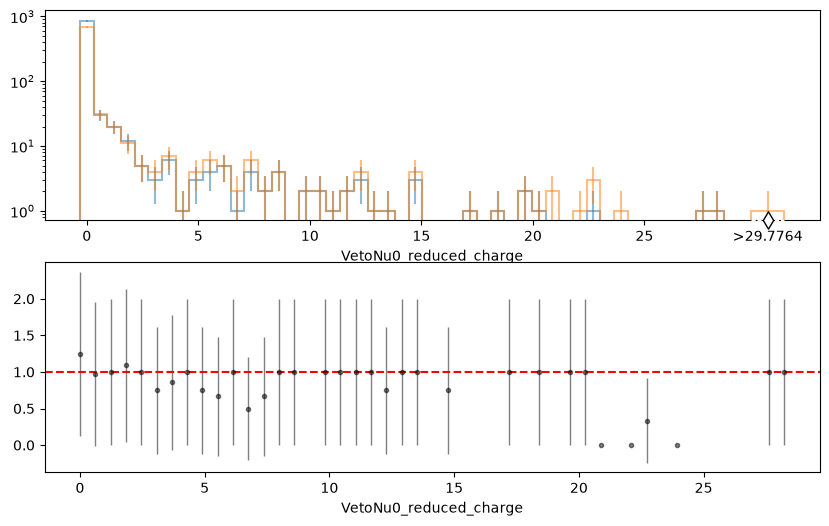

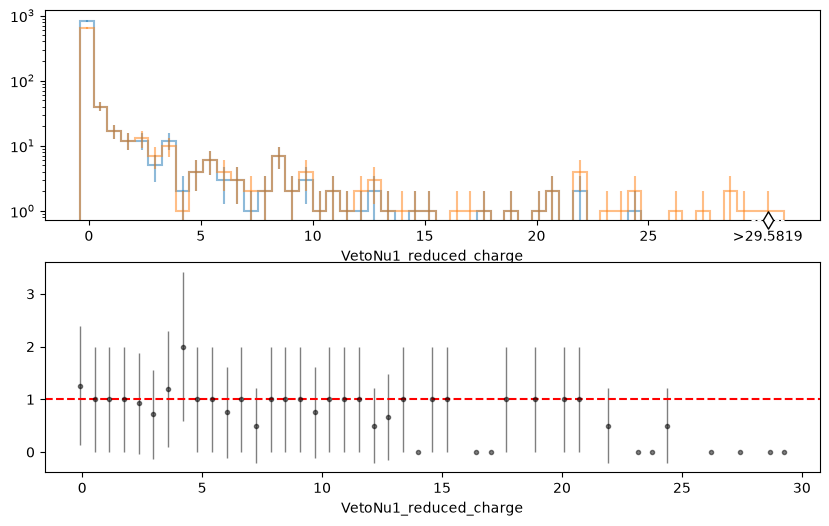

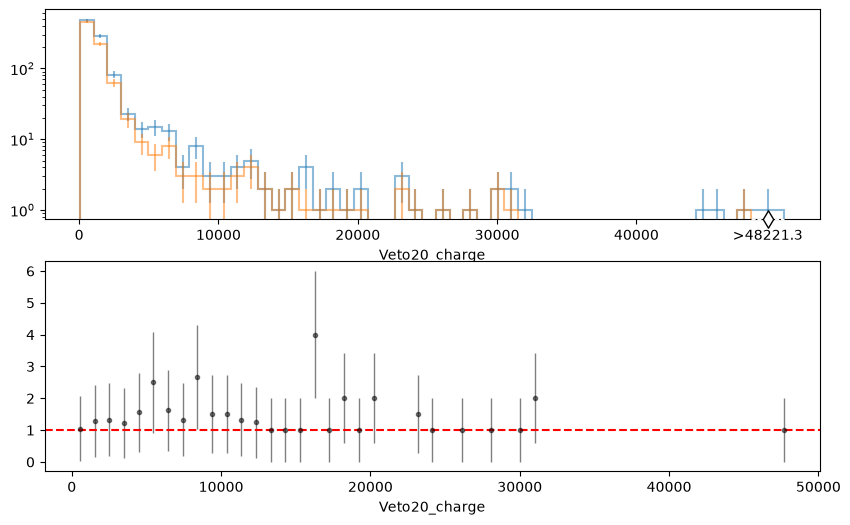

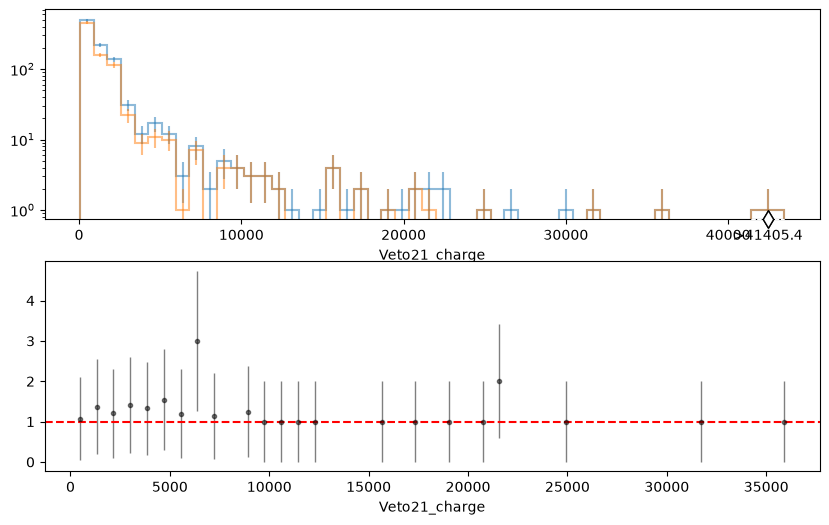

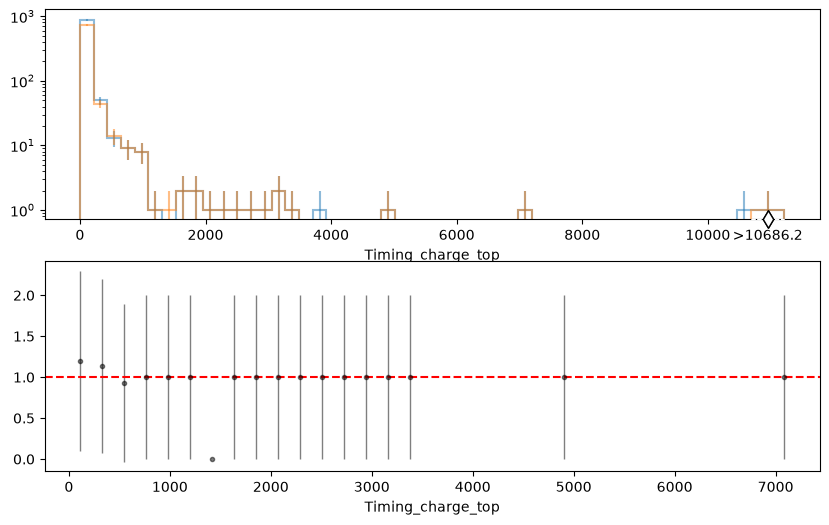

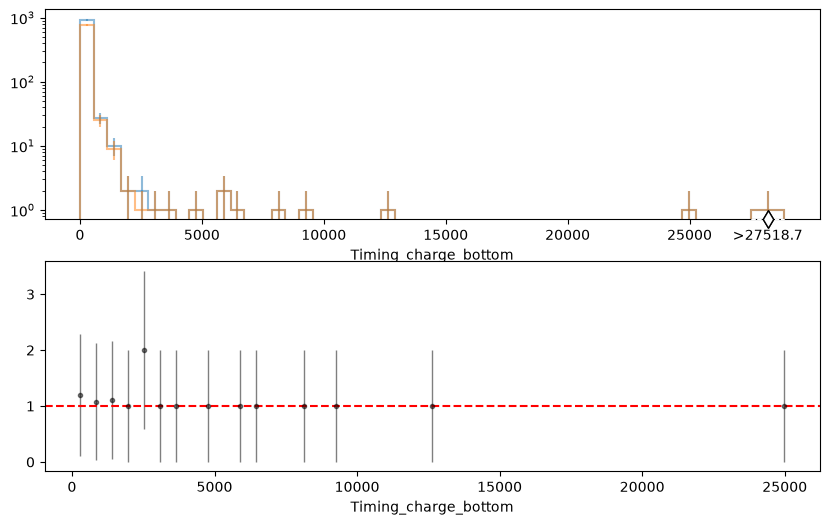

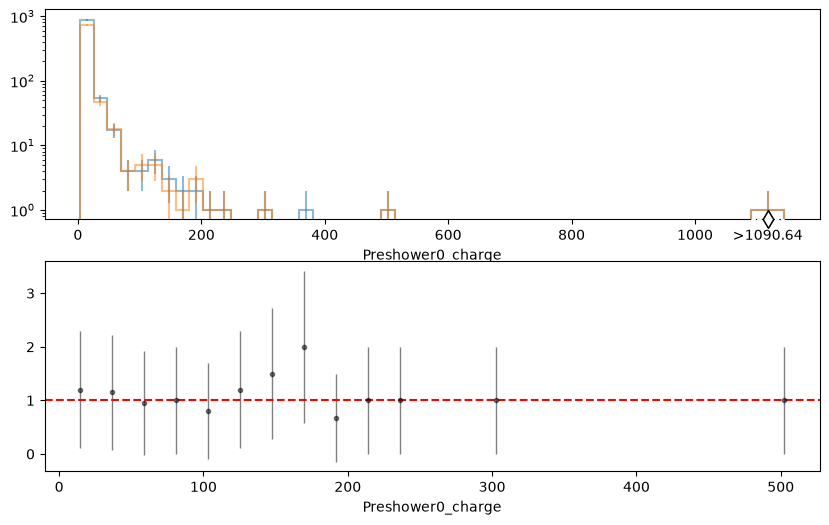

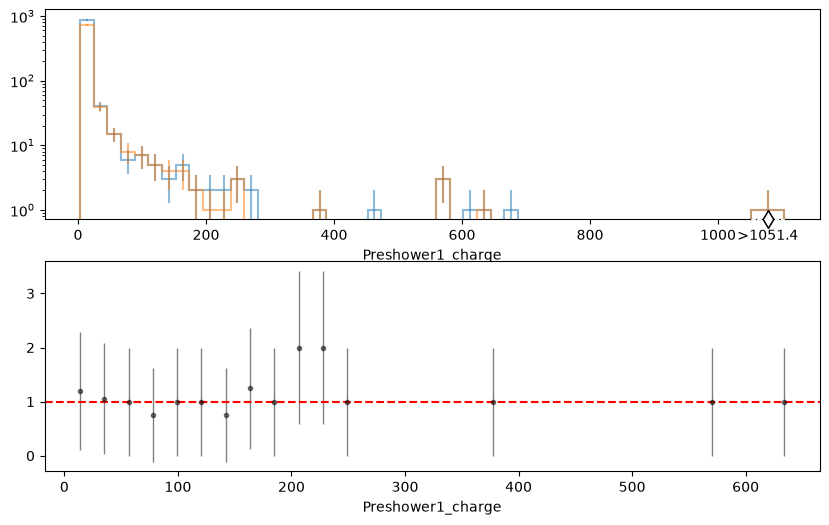

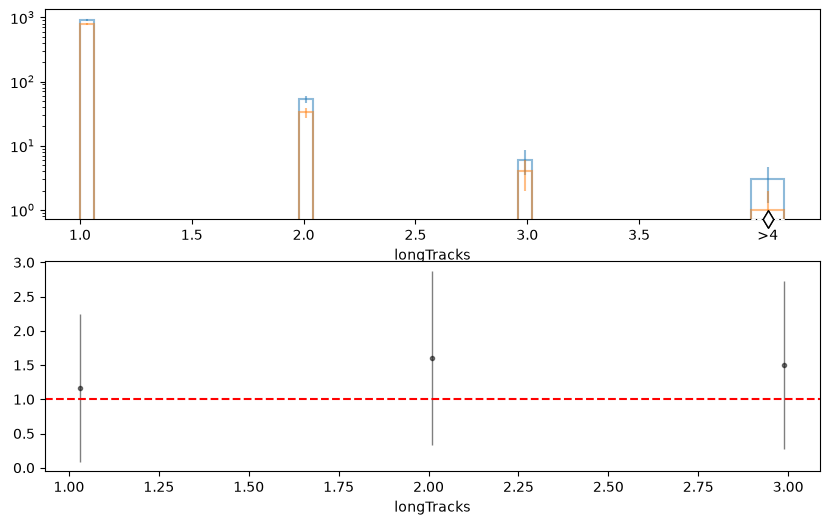

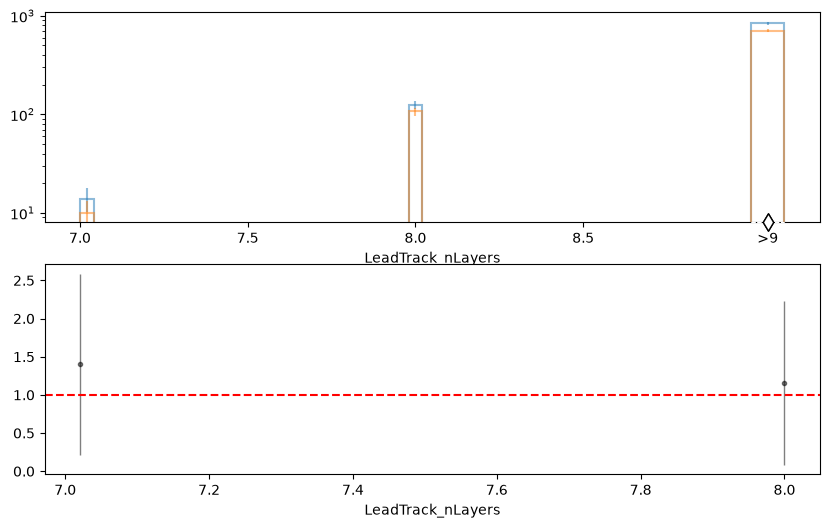

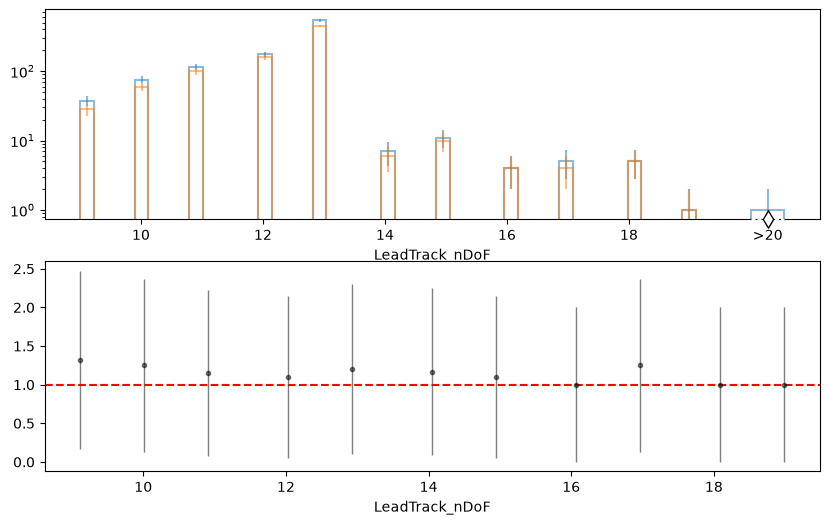

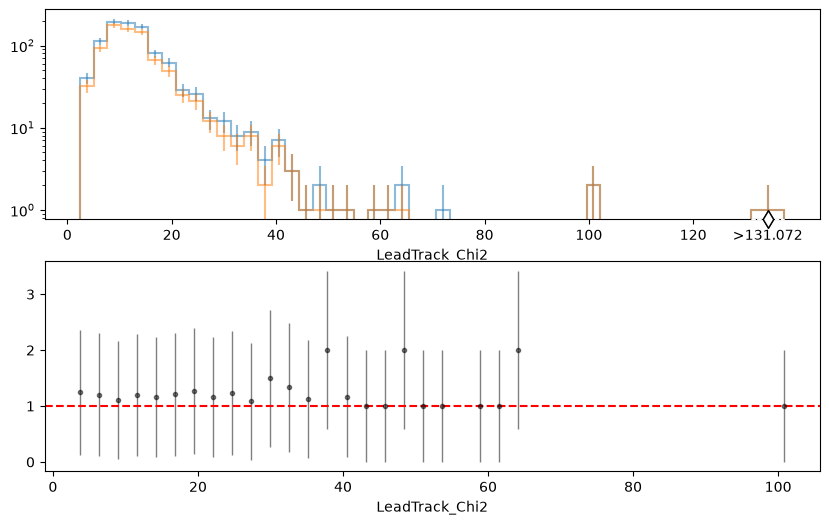

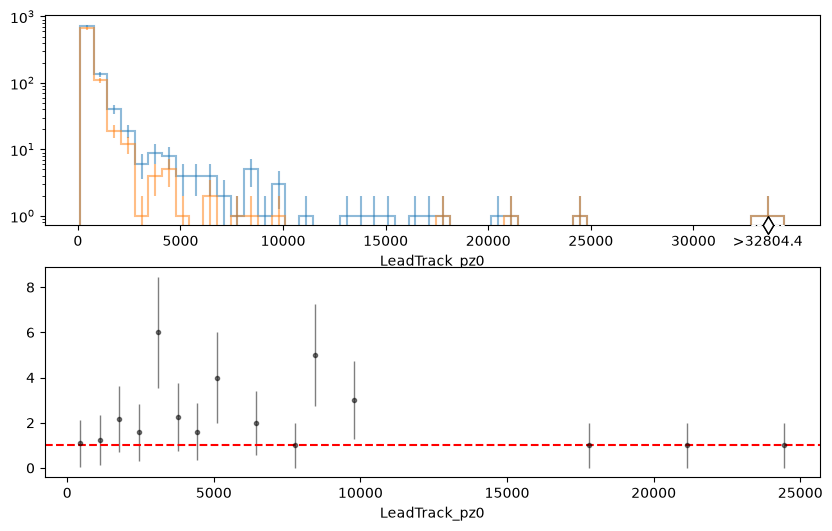

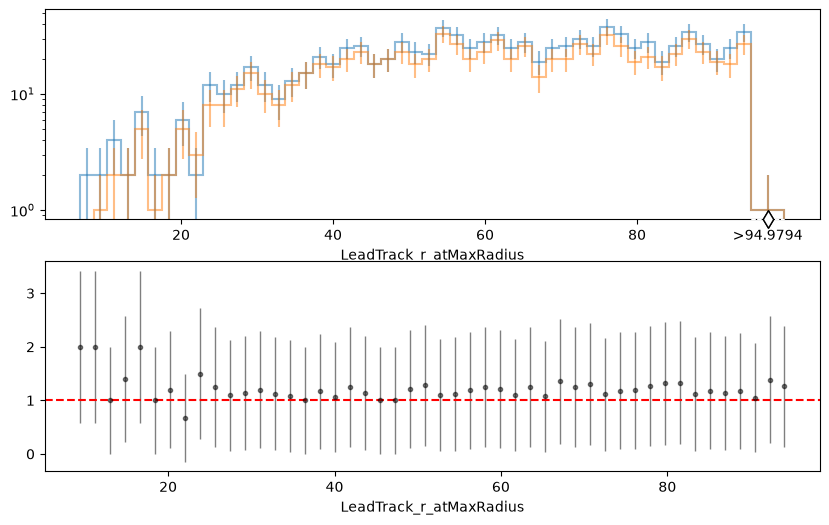

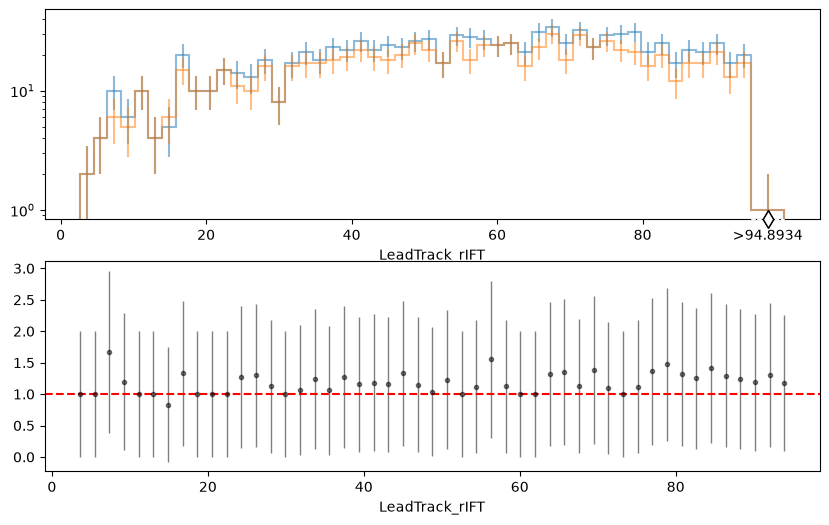

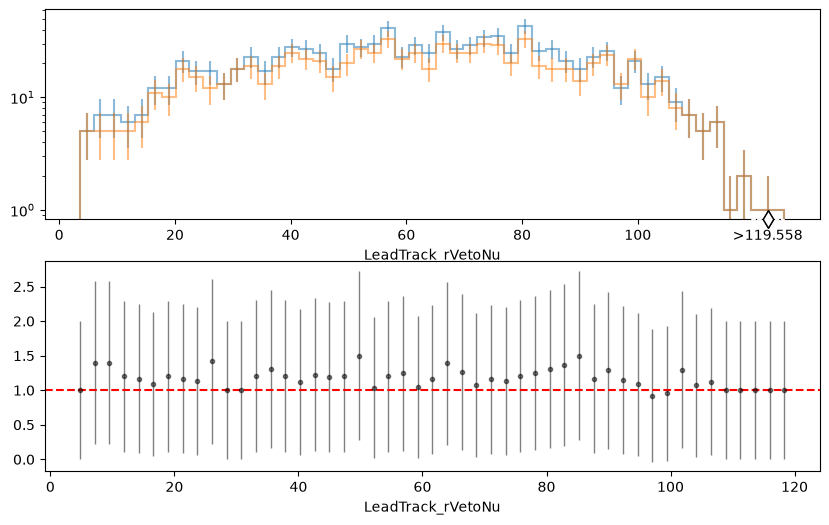

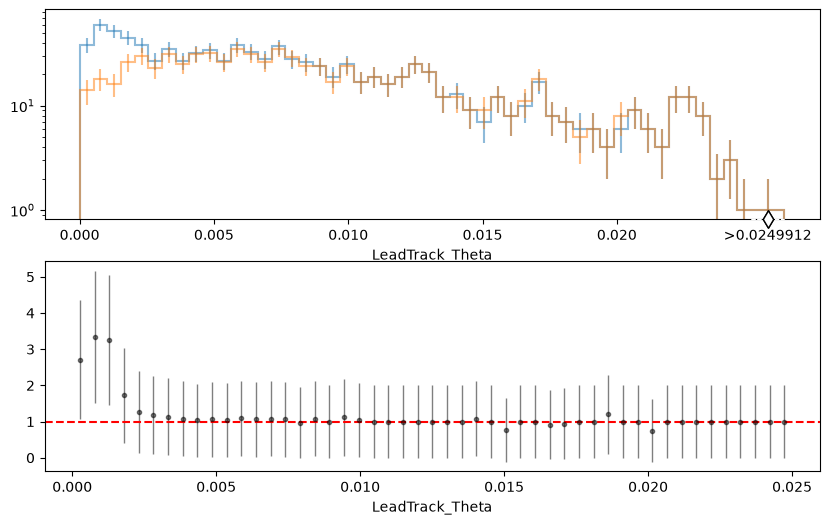

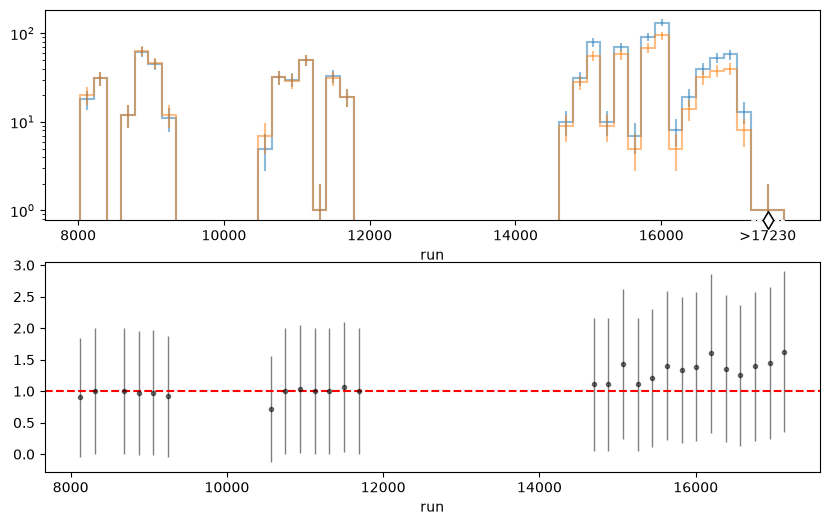

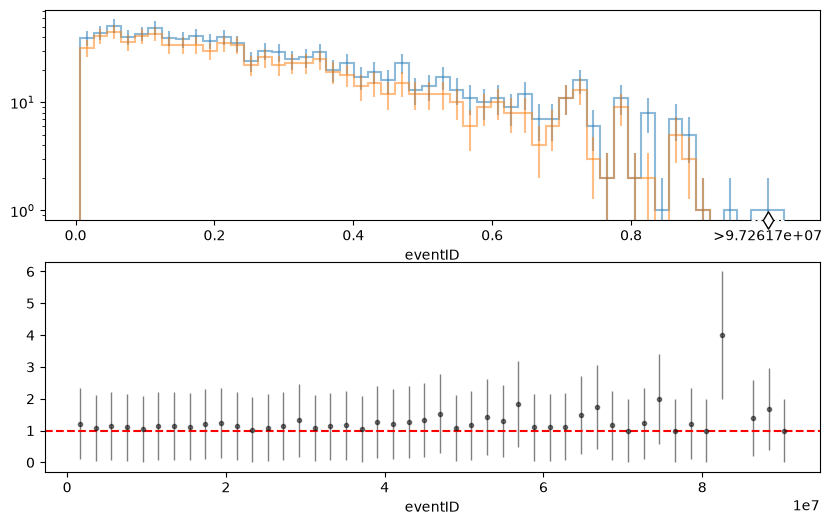

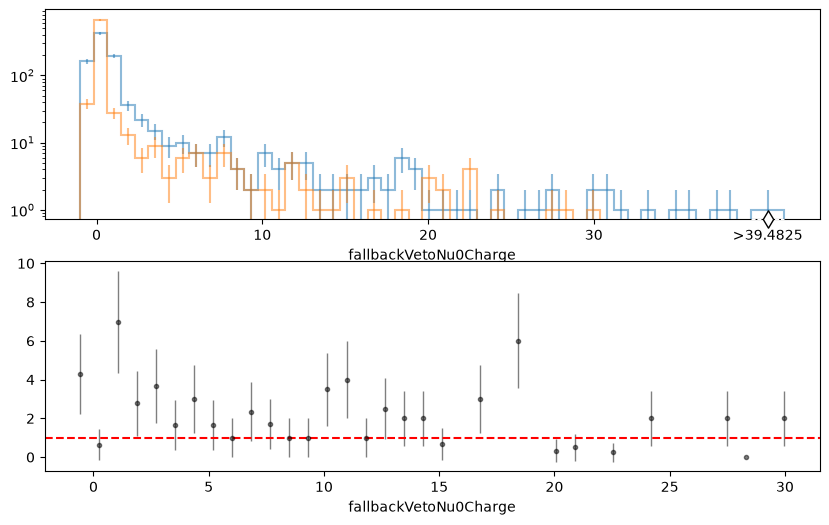

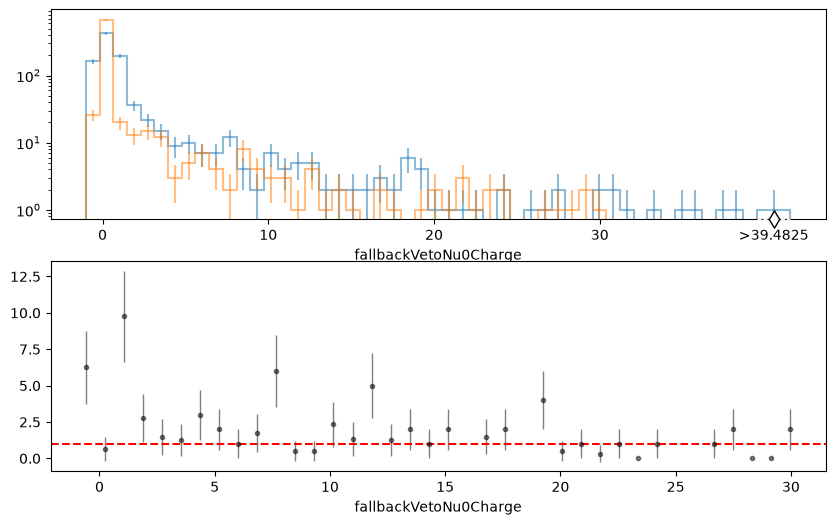

In [52]:
import boost_histogram as bh
import mplhep
for variable, wissals_var in zip(variable_names, variable_name_in_wissals_data):
    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)

    my_var_data = ak.ravel(df_my_full_data[variable])
    wissals_var_data = ak.ravel(df_wissals_data[wissals_var])

    if variable == "LeadTrack_pz0" and wissals_var == "Track_pz_gev":
        my_var_data = my_var_data[my_var_data < 1e5]
        wissals_var_data = wissals_var_data[wissals_var_data < 1e5]


    bins = np.linspace(min(np.min(my_var_data), np.min(wissals_var_data)), max(np.max(my_var_data), np.max(wissals_var_data)), 50)
    
    my_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    her_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))

    my_hist.fill(my_var_data)
    her_hist.fill(wissals_var_data)
    
    mplhep.histplot(my_hist, ax=ax[0], label="My data", alpha=0.5, flow="show")
    mplhep.histplot(her_hist, ax=ax[0], label="Wissal's data", alpha=0.5, flow="show")

    # ax[0].hist(ak.ravel(df_my_full_data[variable]), bins=bins, alpha=0.5, label="My data")
    # ax[0].hist(ak.ravel(df_wissals_data[wissals_var]), bins=bins, alpha=0.5, label="Wissal's data",)
    ax[0].set_xlabel(variable)
    ax[0].set_yscale("log")

    # ratio plot
    ratio = my_hist.view() / her_hist.view()
    ratio_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    ratio_hist.view()[:] = ratio
    mplhep.histplot(ratio_hist, ax=ax[1], label="My data / Wissal's data", alpha=0.5, histtype="errorbar", color="black", flow="show")
    ax[1].set_xlabel(variable)
    ax[1].axhline(y=1, color='r', linestyle='--')
    
    # ax[0].set_xlim(min(np.min(my_var_data), np.min(wissals_var_data)), min(max(np.max(my_var_data), np.max(wissals_var_data)), 1e5))

(0.0, 5000.0)

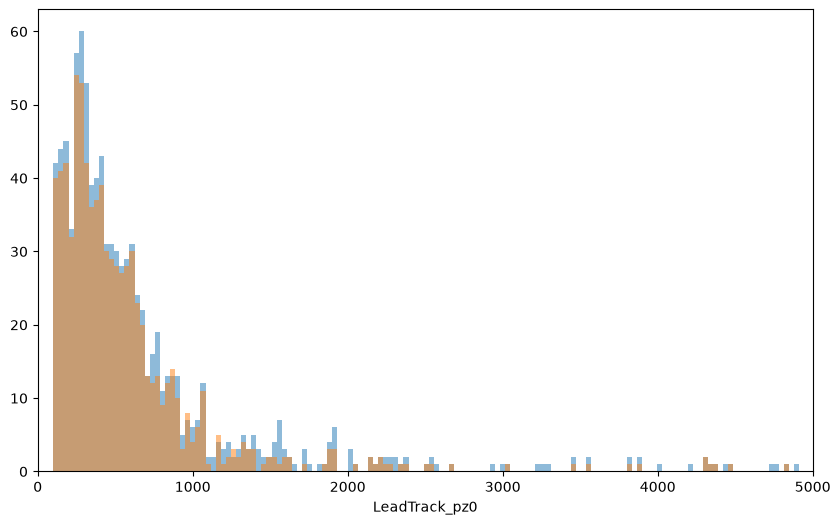

In [53]:
variable = "LeadTrack_pz0"
wissals_var = "Track_pz_gev"

fig, ax = plt.subplots(figsize=(10, 6))

my_var_data = ak.ravel(df_my_full_data[variable])
wissals_var_data = ak.ravel(df_wissals_data[wissals_var])

my_var_data = my_var_data[my_var_data < 1e5]

bins = np.linspace(min(np.min(my_var_data), np.min(wissals_var_data)), max(np.max(my_var_data), np.max(wissals_var_data)), 1000)

ax.hist(ak.ravel(df_my_full_data[variable]), bins=bins, alpha=0.5, label="My data")
ax.hist(ak.ravel(df_wissals_data[wissals_var]), bins=bins, alpha=0.5, label="Wissal's data",)
ax.set_xlabel(variable)
# ax.set_xlim(min(np.min(my_var_data), np.min(wissals_var_data)), min(max(np.max(my_var_data), np.max(wissals_var_data)), 1e5))
ax.set_xlim(0, 5e3)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fc3cb7bf390>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fc3c9aee7b0>, text=[])

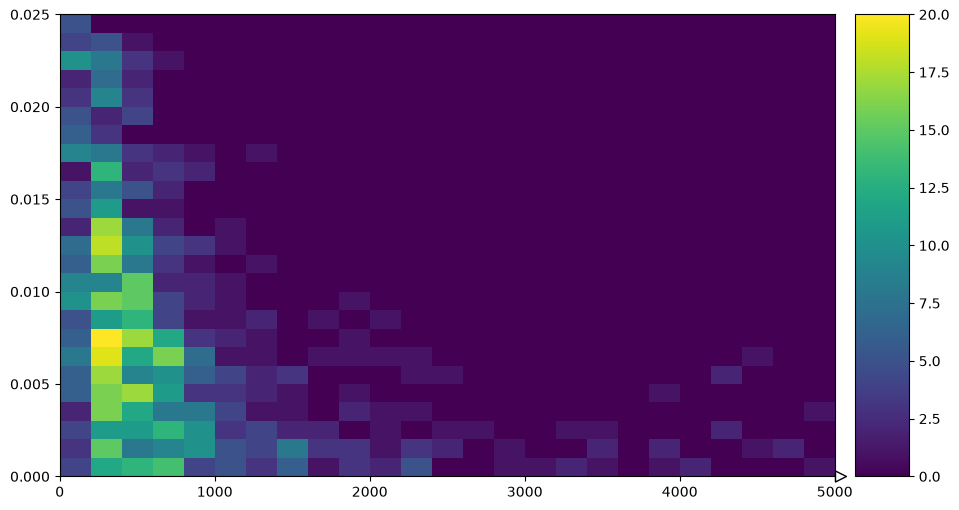

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

h_pz0_vs_theta = bh.Histogram(bh.axis.Regular(25, 0, 5e3), bh.axis.Regular(25, 0, 0.025))

my_pz0 = ak.ravel(df_my_full_data["LeadTrack_pz0"])
my_theta = ak.ravel(df_my_full_data["LeadTrack_Theta"])
h_pz0_vs_theta.fill(my_pz0, my_theta)

mplhep.hist2dplot(h_pz0_vs_theta, ax=ax, cmap="viridis", cbar=True)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fc3cb80a0d0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fc3c9af1550>, text=[])

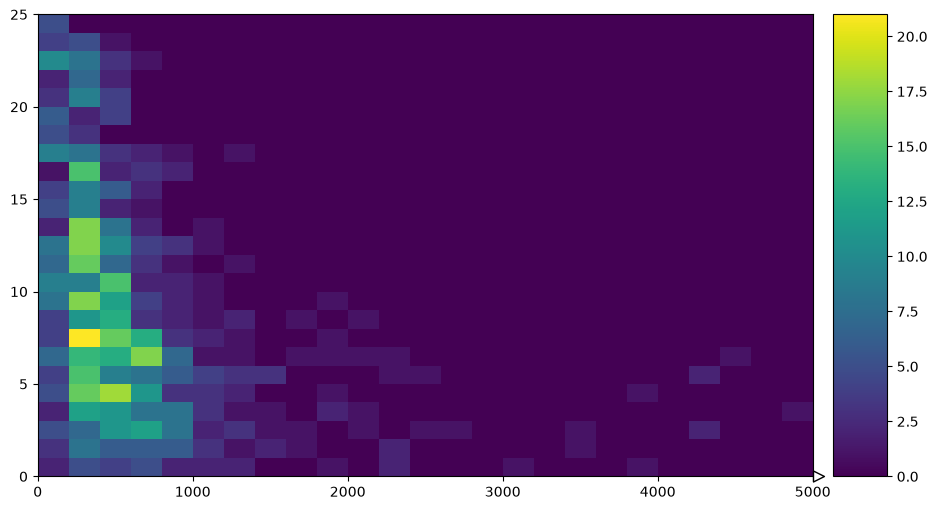

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

h_pz0_vs_theta = bh.Histogram(bh.axis.Regular(25, 0, 5e3), bh.axis.Regular(25, 0, 25))

wissals_pz0 = ak.ravel(df_wissals_data["Track_pz_gev"])
wissals_theta = ak.ravel(df_wissals_data["theta_mrad"])
h_pz0_vs_theta.fill(wissals_pz0, wissals_theta)

mplhep.hist2dplot(h_pz0_vs_theta, ax=ax, cmap="viridis", cbar=True)